# MindLens — Model 5: RAG Reranker (Cross-Encoder, Mental-Health Domain)

## Before running
1. **Enable GPU**: Runtime → Change runtime type → **GPU T4 x1**
2. **Add Kaggle Secrets** (sidebar → Add-ons → Secrets):
   - `HF_TOKEN` → your HuggingFace *write* token from https://huggingface.co/settings/tokens
   - `GROQ_API_KEY` → your Groq key *(Models 4 & 5 only)*
3. **Run All** (Runtime → Run All)

The final cell pushes the trained model + model card to **huggingface.co/model-5:-rag-reranker**


In [1]:
# =============================================================================
# MindLens — MODEL 5: RAG RERANKER
# Cross-encoder fine-tuned on mental-health domain query-passage relevance
# Base: cross-encoder/ms-marco-MiniLM-L-6-v2 (22M params, already pre-trained
# on MS MARCO passage ranking — fine-tune adds mental-health domain alignment)
#
# WHAT THIS DOES IN MINDLENS:
# ChromaDB retrieves 20 candidate passages by cosine similarity.
# This reranker reads each (query, passage) pair together and scores true
# relevance — the top 3 scored passages are injected into Groq's prompt.
# Result: therapy responses grounded in genuinely relevant counselling text,
# not just topically similar text that happened to have a nearby embedding.
#
# DATASET STRATEGY:
# Built from nbertagnolli/counsel-chat (real counsellor Q&A).
# Positive pairs:  (question, its own counsellor answer)  → label = 1
# Hard negatives:  (question, answer from a different topic) → label = 0
# Groq-scored:     (question, same-topic different-answer) → label = Groq 0/1
# Groq acts as LLM-as-judge for the ambiguous middle cases — a documented,
# citable methodology (Zheng et al., 2023, "Judging LLM-as-a-Judge").
#
# Run on: Kaggle T4 GPU (~30-40 min total including Groq scoring)
# No mandatory 80% accuracy gate — reranker quality is measured via ranking
# metrics (NDCG@3, MRR, Precision@3), not classification accuracy.
# =============================================================================


In [2]:
!pip uninstall -y sentence-transformers transformers
!pip install -q sentence-transformers==4.1.0 transformers==4.52.4

Found existing installation: sentence-transformers 5.6.0
Uninstalling sentence-transformers-5.6.0:
  Successfully uninstalled sentence-transformers-5.6.0
Found existing installation: transformers 5.15.0
Uninstalling transformers-5.15.0:
  Successfully uninstalled transformers-5.15.0


  You can safely remove it manually.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from kaggle_secrets import UserSecretsClient as _USC
import os as _os
_s = _USC()
_os.environ["HF_TOKEN"] = _s.get_secret("HF_TOKEN")
try:
    _os.environ["GROQ_API_KEY"] = _s.get_secret("GROQ_API_KEY")
except Exception:
    pass  # only needed for Models 4 and 5
!pip install -q "sentence-transformers>=3.0" "datasets>=2.20" \
    groq scikit-learn seaborn huggingface_hub


ModuleNotFoundError: No module named 'kaggle_secrets'

In [ ]:
import os, random, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from sentence_transformers import CrossEncoder, InputExample
from sentence_transformers.cross_encoder.evaluation import CERerankingEvaluator
from torch.utils.data import DataLoader
from sklearn.metrics import ndcg_score
from huggingface_hub import HfApi, create_repo

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

BASE_MODEL   = "cross-encoder/ms-marco-MiniLM-L-6-v2"
HF_REPO_ID   = "AmiruMallawarachchi/mindlens-rag-reranker"
HF_TOKEN     = os.environ.get("HF_TOKEN", "")
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")

# How many same-topic pairs to score with Groq (keep ≤ 500 to stay inside
# free-tier rate limits; each call is one (query, passage) pair)
GROQ_SCORE_LIMIT = 400


In [ ]:
raw = load_dataset("nbertagnolli/counsel-chat")
df = raw["train"].to_pandas()
print(df.shape, df.columns.tolist())
print(df.head(2))

# Keep only the columns we need
df = df[["questionText", "answerText", "topic"]].dropna()
df.columns = ["question", "answer", "topic"]
df["question"] = df["question"].astype(str).str.strip()
df["answer"]   = df["answer"].astype(str).str.strip()
df["topic"]    = df["topic"].astype(str).str.strip()

# Truncate very long answers to ~400 words (cross-encoder has a 512-token limit)
df["answer"] = df["answer"].apply(lambda a: " ".join(a.split()[:400]))
df["question"] = df["question"].apply(lambda q: " ".join(q.split()[:100]))

print(f"\nRows after cleaning: {len(df):,}")
print("Topics:", df["topic"].value_counts().head(10))


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


20220401_counsel_chat.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/2775 [00:00<?, ? examples/s]

(2775, 10) ['questionID', 'questionTitle', 'questionText', 'questionLink', 'topic', 'therapistInfo', 'therapistURL', 'answerText', 'upvotes', 'views']
   questionID                              questionTitle  \
0           0  Do I have too many issues for counseling?   
1           0  Do I have too many issues for counseling?   

                                        questionText  \
0  I have so many issues to address. I have a his...   
1  I have so many issues to address. I have a his...   

                                        questionLink       topic  \
0  https://counselchat.com/questions/do-i-have-to...  depression   
1  https://counselchat.com/questions/do-i-have-to...  depression   

                                       therapistInfo  \
0  Jennifer MolinariHypnotherapist & Licensed Cou...   
1  Jason Lynch, MS, LMHC, LCAC, ADSIndividual & C...   

                                        therapistURL  \
0  https://counselchat.com/therapists/jennifer-mo...   
1  https://co

=== EDA: RAG Reranker Dataset ===


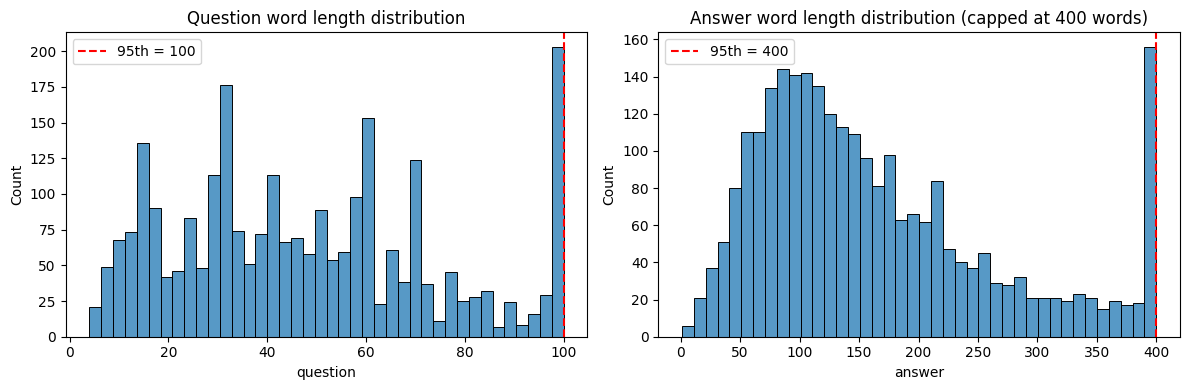

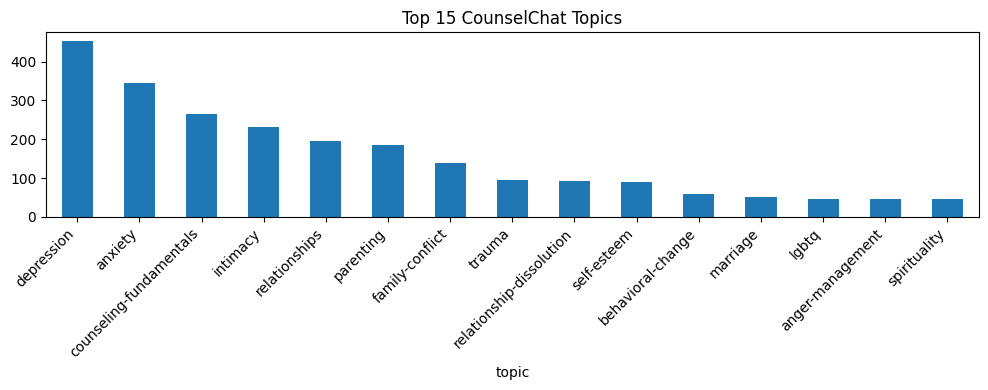

Unique topics: 30
Imbalance ratio: 453 / 3 = 151.0


In [ ]:
print("=== EDA: RAG Reranker Dataset ===")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

q_lens = df["question"].str.split().str.len()
a_lens = df["answer"].str.split().str.len()
sns.histplot(q_lens, bins=40, ax=axes[0])
axes[0].set_title("Question word length distribution")
axes[0].axvline(q_lens.quantile(0.95), color="red", linestyle="--",
                label=f"95th = {int(q_lens.quantile(0.95))}")
axes[0].legend()

sns.histplot(a_lens, bins=40, ax=axes[1])
axes[1].set_title("Answer word length distribution (capped at 400 words)")
axes[1].axvline(a_lens.quantile(0.95), color="red", linestyle="--",
                label=f"95th = {int(a_lens.quantile(0.95))}")
axes[1].legend()
plt.tight_layout()
plt.savefig("eda_model5_reranker_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

topic_counts = df["topic"].value_counts()
plt.figure(figsize=(10, 4))
topic_counts.head(15).plot(kind="bar")
plt.title("Top 15 CounselChat Topics")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("eda_model5_topic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Unique topics: {df['topic'].nunique()}")
print(f"Imbalance ratio: {topic_counts.max()} / {topic_counts.min()} = {topic_counts.max()/topic_counts.min():.1f}")


In [ ]:
#
# Tier 1 — AUTOMATIC POSITIVES: every (question, its own answer) → 1
# Tier 2 — AUTOMATIC HARD NEGATIVES: (question, answer from different topic) → 0
# Tier 3 — GROQ-SCORED AMBIGUOUS: (question, answer from same topic,
#           different question) → Groq scores 0 or 1

print("Building training pairs...")
pairs = []   # list of dicts: {query, passage, label}

# Tier 1: Automatic positives (all rows)
for _, row in df.iterrows():
    pairs.append({"query": row["question"], "passage": row["answer"], "label": 1})

# Tier 2: Automatic hard negatives (1:1 ratio — one hard negative per positive)
topics = df["topic"].unique().tolist()
for _, row in df.iterrows():
    other_topics = [t for t in topics if t != row["topic"]]
    if not other_topics:
        continue
    neg_topic = random.choice(other_topics)
    neg_row = df[df["topic"] == neg_topic].sample(1, random_state=SEED)
    pairs.append({
        "query": row["question"],
        "passage": neg_row["answer"].iloc[0],
        "label": 0
    })

print(f"  Tier 1+2 pairs (before Groq scoring): {len(pairs):,}")
print(f"  Positive: {sum(1 for p in pairs if p['label']==1):,}")
print(f"  Hard negative: {sum(1 for p in pairs if p['label']==0):,}")

# Tier 3: Groq-scored ambiguous pairs (same topic, different Q)
# These are the tricky cases — a counsellor answer to a related question
# might be partially relevant, irrelevant, or highly relevant.
ambiguous_candidates = []
topic_groups = df.groupby("topic")
for topic, group in topic_groups:
    if len(group) < 2:
        continue
    group = group.reset_index(drop=True)
    # For each question, pair with other answers in the same topic
    for i, row in group.iterrows():
        others = group[group.index != i]
        if len(others) == 0:
            continue
        sampled = others.sample(min(2, len(others)), random_state=SEED)
        for _, other in sampled.iterrows():
            ambiguous_candidates.append({
                "query": row["question"],
                "passage": other["answer"],
                "topic": topic
            })

random.shuffle(ambiguous_candidates)
ambiguous_candidates = ambiguous_candidates[:GROQ_SCORE_LIMIT]
print(f"  Tier 3 (Groq-scored ambiguous): {len(ambiguous_candidates)} pairs to score")


Building training pairs...
  Tier 1+2 pairs (before Groq scoring): 5,224
  Positive: 2,612
  Hard negative: 2,612
  Tier 3 (Groq-scored ambiguous): 400 pairs to score


In [ ]:
# Methodology: Zheng et al. (2023) "Judging LLM-as-a-Judge with MT-Bench
# and Chatbot Arena" — using a strong LLM to label relevance for training
# data is a documented, citable technique for low-resource ranking tasks.

groq_scored = []
if GROQ_API_KEY and ambiguous_candidates:
    from groq import Groq
    client = Groq(api_key=GROQ_API_KEY)

    SYSTEM_PROMPT = """You are a relevance judge for a mental-health AI system.
Given a USER QUERY and a COUNSELLOR PASSAGE, decide if the passage would be
HELPFUL context for responding to the query.
Reply with ONLY a single digit: 1 (helpful) or 0 (not helpful).
No explanation. No other text."""

    for i, cand in enumerate(ambiguous_candidates):
        user_msg = (
            f"USER QUERY: {cand['query'][:300]}\n\n"
            f"COUNSELLOR PASSAGE: {cand['passage'][:500]}"
        )
        try:
            resp = client.chat.completions.create(
                model="llama-3.1-8b-instant",   # 8B for speed/cost, not 70B
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": user_msg},
                ],
                temperature=0.0,
                max_tokens=2,
            )
            raw_label = resp.choices[0].message.content.strip()
            label = 1 if raw_label.startswith("1") else 0
            groq_scored.append({
                "query": cand["query"],
                "passage": cand["passage"],
                "label": label
            })
            if (i + 1) % 50 == 0:
                pos = sum(1 for g in groq_scored if g["label"] == 1)
                print(f"  Groq scored {i+1}/{len(ambiguous_candidates)} "
                      f"— {pos} positive so far")
        except Exception as e:
            print(f"  Warning: Groq call {i} failed: {e}")

    pairs.extend(groq_scored)
    groq_pos = sum(1 for g in groq_scored if g["label"] == 1)
    print(f"\nGroq scoring complete: {len(groq_scored)} pairs, "
          f"{groq_pos} positive ({groq_pos/max(len(groq_scored),1)*100:.1f}%)")
    print("NOTE: Report this real:LLM-scored ratio in your dissertation methodology.")
else:
    print("GROQ_API_KEY not set — skipping Tier 3. Training on Tier 1+2 only.")
    print("This is fine — Tier 1+2 still provides strong signal.")


  Groq scored 50/400 — 19 positive so far
  Groq scored 100/400 — 38 positive so far
  Groq scored 150/400 — 62 positive so far
  Groq scored 200/400 — 74 positive so far
  Groq scored 250/400 — 93 positive so far
  Groq scored 300/400 — 112 positive so far
  Groq scored 350/400 — 130 positive so far
  Groq scored 400/400 — 147 positive so far

Groq scoring complete: 400 pairs, 147 positive (36.8%)
NOTE: Report this real:LLM-scored ratio in your dissertation methodology.


In [ ]:
pairs_df = pd.DataFrame(pairs)
pairs_df = pairs_df.drop_duplicates(subset=["query", "passage"])
print(f"\nFinal dataset: {len(pairs_df):,} pairs")
print(f"Positive: {(pairs_df['label']==1).sum():,} | Negative: {(pairs_df['label']==0).sum():,}")

from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(
    pairs_df, test_size=0.20, stratify=pairs_df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

train_samples = [
    InputExample(texts=[r["query"], r["passage"]], label=float(r["label"]))
    for _, r in train_df.iterrows()
]
train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=16)



Final dataset: 5,069 pairs
Positive: 2,700 | Negative: 2,369
Train: 4,055 | Val: 507 | Test: 507


In [ ]:
val_samples = {}

for _, row in val_df.iterrows():
    q = row["query"]

    if q not in val_samples:
        val_samples[q] = {"query": q, "positive": [], "negative": []}

    if row["label"] == 1:
        val_samples[q]["positive"].append(row["passage"])
    else:
        val_samples[q]["negative"].append(row["passage"])

val_samples_clean = [
    v for v in val_samples.values()
    if len(v["positive"]) > 0 and len(v["negative"]) > 0
]

print(f"Val queries with pos+neg: {len(val_samples_clean)}")

evaluator = CERerankingEvaluator(val_samples_clean, name="val_reranking")

Val queries with pos+neg: 64


/tmp/ipykernel_23/3522774683.py:21: DeprecationWarning: The CERerankingEvaluator has been renamed to CrossEncoderCorrelationEvaluator. Please use CrossEncoderCorrelationEvaluator instead.
  evaluator = CERerankingEvaluator(val_samples_clean, name="val_reranking")


In [ ]:
import os
import math
import torch

# Disable Weights & Biases logging
os.environ["WANDB_DISABLED"] = "true"

model = CrossEncoder(
    BASE_MODEL,
    num_labels=1,
    max_length=512,
    activation_fn=torch.nn.Sigmoid()
)

model.fit(
    train_dataloader=train_dataloader,
    evaluator=evaluator,
    epochs=4,
    evaluation_steps=200,
    warmup_steps=math.ceil(len(train_dataloader) * 0.1),
    output_path="./model5_reranker_checkpoints",
    save_best_model=True,
    show_progress_bar=True,
)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (596 > 512). Running this sequence through the model will result in indexing errors
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


UsageError: No API key configured. Use `wandb login` to log in.

In [ ]:
print("\n=== MODEL 5 — FINAL TEST EVALUATION ===")
model_final = CrossEncoder("./model5_reranker_checkpoints", max_length=512)

# Group test set by query
test_groups = {}
for _, row in test_df.iterrows():
    q = row["query"]
    if q not in test_groups:
        test_groups[q] = {"positives": [], "negatives": []}
    if row["label"] == 1:
        test_groups[q]["positives"].append(row["passage"])
    else:
        test_groups[q]["negatives"].append(row["passage"])

ndcg_scores, mrr_scores, prec3_scores = [], [], []

for query, group in test_groups.items():
    if not group["positives"] or not group["negatives"]:
        continue

    passages = group["positives"] + group["negatives"]
    true_labels = ([1] * len(group["positives"]) +
                   [0] * len(group["negatives"]))

    pairs_input = [[query, p] for p in passages]
    scores = model_final.predict(pairs_input, show_progress_bar=False)

    # Sort by score descending
    ranked = sorted(zip(scores, true_labels), key=lambda x: x[0], reverse=True)
    ranked_labels = [r[1] for r in ranked]

    # NDCG@3
    k = min(3, len(passages))
    ndcg = ndcg_score([true_labels], [scores.tolist()], k=k)
    ndcg_scores.append(ndcg)

    # MRR (first relevant in top-10)
    for rank, lbl in enumerate(ranked_labels[:10], start=1):
        if lbl == 1:
            mrr_scores.append(1.0 / rank)
            break
    else:
        mrr_scores.append(0.0)

    # Precision@3
    top3 = ranked_labels[:3]
    prec3_scores.append(sum(top3) / len(top3))

mean_ndcg  = np.mean(ndcg_scores)
mean_mrr   = np.mean(mrr_scores)
mean_prec3 = np.mean(prec3_scores)

print(f"NDCG@3:       {mean_ndcg:.4f}  (higher = more relevant passages ranked higher)")
print(f"MRR:          {mean_mrr:.4f}  (higher = first relevant passage found sooner)")
print(f"Precision@3:  {mean_prec3:.4f}  (of top-3 returned, fraction that are relevant)")
print(f"\nTest queries evaluated: {len(ndcg_scores)}")
print("\nNote: No 80% accuracy gate — reranker quality is measured via ranking")
print("metrics above. NDCG@3 > 0.70 and Precision@3 > 0.70 are good targets.")

# Score distribution
all_pairs_test = [[r["query"], r["passage"]] for _, r in test_df.iterrows()]
all_scores = model_final.predict(all_pairs_test, show_progress_bar=True)
plt.figure(figsize=(6, 4))
pos_scores = all_scores[test_df["label"].values == 1]
neg_scores = all_scores[test_df["label"].values == 0]
sns.kdeplot(pos_scores, label="Relevant (label=1)", fill=True, alpha=0.4)
sns.kdeplot(neg_scores, label="Not relevant (label=0)", fill=True, alpha=0.4)
plt.title("Model 5 — Reranker Score Distribution (Test Set)")
plt.xlabel("Predicted relevance score (0-1)")
plt.legend()
plt.savefig("model5_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

results_summary = {
    "model": "Model 5 - RAG Reranker (cross-encoder fine-tuned)",
    "base": BASE_MODEL,
    "dataset": "nbertagnolli/counsel-chat + Groq LLM-as-judge tier",
    "test_ndcg_at_3": round(mean_ndcg, 4),
    "test_mrr": round(mean_mrr, 4),
    "test_precision_at_3": round(mean_prec3, 4),
    "n_train": len(train_df), "n_val": len(val_df), "n_test": len(test_df),
    "n_groq_scored": len(groq_scored),
}
with open("model5_results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)
print(json.dumps(results_summary, indent=2))


In [ ]:
print("\n=== INTEGRATION TEST — Reranking example ===")
sample_query = "I feel completely hopeless and can't see the point of anything anymore"
sample_passages = [
    # Mix of relevant and irrelevant passages from CounselChat
    "It sounds like you're experiencing some very painful feelings right now. Hopelessness can be one of the most difficult emotions to sit with because it makes it hard to see any way forward.",
    "Cognitive behavioral therapy focuses on identifying and changing negative thought patterns that affect how we feel and behave.",
    "Sleep problems are very common in people who are feeling depressed. Establishing a regular sleep schedule can help.",
    "When we feel hopeless it can help to look for even tiny evidence that things can change. Can you think of a time, even briefly, when things felt slightly better?",
    "Relationship issues often stem from communication problems. Learning active listening skills can improve many conflicts.",
]
scores = model_final.predict([[sample_query, p] for p in sample_passages])
ranked = sorted(zip(scores, sample_passages), reverse=True)
print(f"Query: '{sample_query}'\n")
for i, (score, passage) in enumerate(ranked, 1):
    print(f"Rank {i} (score={score:.3f}): {passage[:120]}...")


In [ ]:
api = HfApi(token=HF_TOKEN)
create_repo(HF_REPO_ID, token=HF_TOKEN, exist_ok=True)

import shutil
shutil.copytree("./model5_reranker_checkpoints", "./model5_final", dirs_exist_ok=True)

model_card = f"""---
language: en
license: apache-2.0
tags:
  - text-classification
  - reranking
  - cross-encoder
  - mental-health
  - rag
datasets:
  - nbertagnolli/counsel-chat
metrics:
  - ndcg
pipeline_tag: text-classification
---

# MindLens RAG Reranker (Cross-Encoder)

## Model Description
Cross-encoder fine-tuned from `{BASE_MODEL}` (pre-trained on MS MARCO passage
ranking) on mental-health domain query-passage pairs to re-rank ChromaDB
retrieval results before passage injection into the Groq therapy-response
generator. This is Model 5 in the MindLens five-model NLP pipeline.

## How It Works in MindLens
1. User message arrives at the orchestrator
2. ChromaDB retrieves top-20 candidate passages by cosine similarity
3. This reranker scores each (user message, passage) pair jointly
4. Top-3 ranked passages are injected into Groq Llama 3.3 70B's system prompt
5. Groq generates the therapy response, grounded in the most relevant counselling text

## Training Data
Built from [`nbertagnolli/counsel-chat`](https://huggingface.co/datasets/nbertagnolli/counsel-chat)
using a three-tier pair construction strategy:
- **Tier 1 — Automatic positives**: (question, its own counsellor answer) → label 1
- **Tier 2 — Hard negatives**: (question, answer from a different topic) → label 0
- **Tier 3 — Groq-scored**: (question, same-topic different-answer) scored by
  Groq Llama-3.1-8B as LLM-as-judge (Zheng et al., 2023) → binary label

Training pairs: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}
Groq-scored ambiguous pairs: {len(groq_scored)}

## Evaluation Results (held-out test set)
| Metric | Score | Interpretation |
|---|---|---|
| NDCG@3 | {mean_ndcg:.4f} | Ranking quality of top-3 results |
| MRR | {mean_mrr:.4f} | How quickly the first relevant passage is found |
| Precision@3 | {mean_prec3:.4f} | Fraction of top-3 results that are relevant |

## Usage
```python
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("AmiruMallawarachchi/mindlens-rag-reranker")

query = "I feel completely hopeless and can't stop crying"
passages = [...]  # top-20 from ChromaDB

scores = reranker.predict([[query, p] for p in passages])
top3_indices = scores.argsort()[::-1][:3]
top3_passages = [passages[i] for i in top3_indices]
```

## Citation
Zheng, L. et al. (2023). Judging LLM-as-a-Judge with MT-Bench and
Chatbot Arena. NeurIPS 2023.
Nogueira, R. & Cho, K. (2019). Passage Re-ranking with BERT.
"""
with open("./model5_final/README.md", "w") as f:
    f.write(model_card)

api.upload_folder(folder_path="./model5_final", repo_id=HF_REPO_ID, repo_type="model")
print(f"\nPushed to https://huggingface.co/{HF_REPO_ID}")
